# InfoMap

| | G_internal | G_combined |
|---|---|---|
| **Type** | Directed, unweighted | Undirected, weighted (BC score) |
| **Edges** | Citation links only | Citations + bibliographic coupling |
| **CD input** | `graph_internal_2020.gpickle` | `graph_combined_2020.gpickle` |
| **InfoMap variant** | Map Equation (directed flow) | Map Equation (w/ weights) |

In [17]:
import os, re, time, pickle, textwrap, warnings
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import infomap as infomap_lib
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import normalized_mutual_info_score, mutual_info_score
from cdlib import NodeClustering, evaluation

GRAPH_DIR     = '../00_graph_construction/output/graphs'
INTERNAL_PATH = os.path.join(GRAPH_DIR, 'graph_internal_2020.gpickle')
COMBINED_PATH = os.path.join(GRAPH_DIR, 'graph_combined_2020.gpickle')

N_RUN         = 100
TOP_N_COMMS   = 20
TOP_K         = 5
MIN_COMM_SIZE = 10

## Graph loading

In [2]:
def load_graph(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

G_internal = load_graph(INTERNAL_PATH)
G_combined = load_graph(COMBINED_PATH)
G_internal_undir = G_internal.to_undirected()

# Ensure weights
for u, v, d in G_combined.edges(data=True):
    if 'weight' not in d:
        d['weight'] = 1.0

w = [d['weight'] for _, _, d in G_combined.edges(data=True)]

print(f"G_internal   {G_internal.number_of_nodes():>7,} nodes   {G_internal.number_of_edges():>8,} edges  (directed, unweighted)")
print(f"G_combined   {G_combined.number_of_nodes():>7,} nodes   {G_combined.number_of_edges():>8,} edges  "
      f"(undirected, weighted)  median_w={np.median(w):.3f}")

G_internal    55,078 nodes    217,925 edges  (directed, unweighted)
G_combined    58,627 nodes    590,157 edges  (undirected, weighted)  median_w=0.249


## Attribute statistics

In [3]:
# ===========================================================================
# FOS / SDG label parsing (shared across all CD notebooks)
# ===========================================================================
_LEVEL_RE = {
    'macro': re.compile(r'^\d{2}\s'),   # "03 medical and health sciences"
    'sub':   re.compile(r'^\d{4}\s'),   # "0302 clinical medicine"
}

def parse_labels(val, level='sub'):
    """Split semicolon-separated FOS/SDG string into atomic labels."""
    if not val:
        return []
    parts = [p.strip() for p in str(val).split(';') if p.strip()]
    pattern = _LEVEL_RE.get(level)
    return [p for p in parts if pattern.match(p)] if pattern else parts

# ===========================================================================
# Attribute statistics
# ===========================================================================
def _split_labels(raw_value):
    return [p.strip() for p in re.split(r';\s*', str(raw_value)) if p.strip()]

def _extract_l2(counter):
    l2 = Counter()
    for label, count in counter.items():
        if re.match(r'^\d{2}', label):
            l2[label[:2]] += count
    return l2

def compute_attr_stats(G, attributes=('FOS', 'SDG')):
    stats = {}
    for attr in attributes:
        counts = Counter()
        n_nodes = 0
        for _, data in G.nodes(data=True):
            val = data.get(attr)
            if not val:
                continue
            n_nodes += 1
            counts.update(_split_labels(val))
        stats[attr] = {'counts': counts, 'n_nodes': n_nodes}
        if attr == 'FOS':
            stats['FOS_L2'] = {'counts': _extract_l2(counts), 'n_nodes': n_nodes}
    return stats

def compare_attr_stats(stats_int, stats_comb, key):
    n_i = stats_int[key]['n_nodes']
    n_c = stats_comb[key]['n_nodes']
    all_labels = sorted(set(stats_int[key]['counts']) | set(stats_comb[key]['counts']))
    rows = []
    for label in all_labels:
        ci = stats_int[key]['counts'].get(label, 0)
        cc = stats_comb[key]['counts'].get(label, 0)
        rows.append({
            'label': label,
            'int_cnt': ci,  'int_pct': ci / n_i * 100 if n_i else 0,
            'comb_cnt': cc, 'comb_pct': cc / n_c * 100 if n_c else 0,
        })
    return pd.DataFrame(rows)

s_int  = compute_attr_stats(G_internal)
s_comb = compute_attr_stats(G_combined)

pd.concat([
    compare_attr_stats(s_int, s_comb, 'FOS').assign(level='detail'),
    compare_attr_stats(s_int, s_comb, 'FOS_L2').assign(level='L2'),
], ignore_index=True).to_csv('FOS_stats.csv', index=False)

compare_attr_stats(s_int, s_comb, 'SDG') \
    .sort_values('int_cnt', ascending=False) \
    .to_csv('SDG_stats.csv', index=False)

print('FOS_stats.csv  SDG_stats.csv  created')

FOS_stats.csv  SDG_stats.csv  created


## InfoMap - Map Equation optimisation

InfoMap (Rosvall and Bergstrom, 2008) detects communities as regions that trap random-walk flow.

- Objective: minimize Map Equation codelength
- Variant: `Infomap`
- `G_internal`: directed, unweighted
- `G_combined`: weighted on `weight`

### Ensemble and medoid selection

To improve robustness on degenerate solutions:

1. Run InfoMap 100 times (seeds 1..100)
2. Compute pairwise NMI (100x100 matrix)
3. Select the medoid run (highest average NMI)

The medoid is used as representative partition for downstream analysis.

In [4]:
def compute_nmi_matrix(labels_list, n_workers=8):
    """Pairwise NMI between all runs (parallelized)."""
    n = len(labels_list)
    mat = np.eye(n)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

    def _nmi(pair):
        i, j = pair
        return i, j, normalized_mutual_info_score(
            labels_list[i], labels_list[j], average_method='arithmetic'
        )

    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        for i, j, v in pool.map(_nmi, pairs):
            mat[i, j] = mat[j, i] = v
    return mat


def select_medoid(nmi_matrix):
    """Return (medoid_index, per-run_avg_nmi, upper-triangle_values)."""
    n = nmi_matrix.shape[0]
    avg_nmi = (nmi_matrix.sum(axis=1) - 1.0) / (n - 1)
    return int(np.argmax(avg_nmi)), avg_nmi, nmi_matrix[np.triu_indices(n, k=1)]


def run_infomap_ensemble(G, graph_name, is_directed=True,
                         weight_attr='weight', n_runs=100, base_seed=1):
    """Run InfoMap n_runs times, return medoid partition + stats."""
    t0 = time.time()
    nodes_list = list(G.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes_list)}

    flags = '--directed --silent' if is_directed else '--silent'

    print(f"--- InfoMap ensemble: {graph_name} ---")
    print(f"    Runs: {n_runs} | Directed: {is_directed} "
          f"| Weights: {weight_attr if not is_directed else 'unit'}")

    results = []
    for seed in range(base_seed, base_seed + n_runs):
        im = infomap_lib.Infomap(flags)

        for u, v, data in G.edges(data=True):
            w = data.get(weight_attr, 1.0) if not is_directed else 1.0
            im.addLink(node_to_idx[u], node_to_idx[v], w)

        im.run(seed=seed)

        comm_dict = defaultdict(list)
        for node in im.tree:
            if node.isLeaf:
                comm_dict[node.moduleIndex()].append(nodes_list[node.physicalId])
        communities = list(comm_dict.values())

        labels = np.full(len(nodes_list), -1, dtype=np.int32)
        for cid, comm in enumerate(communities):
            for node in comm:
                labels[node_to_idx[node]] = cid

        results.append({
            'seed': seed,
            'labels': labels,
            'clustering': NodeClustering(communities, graph=G, method_name='infomap'),
            'n_communities': len(communities),
        })

    print(f"    InfoMap runs: {time.time() - t0:.1f}s")

    mod_graph = G.to_undirected() if is_directed else G
    t_nmi = time.time()
    nmi_matrix = compute_nmi_matrix([r['labels'] for r in results])
    print(f"    NMI matrix: {time.time() - t_nmi:.1f}s")

    medoid_idx, avg_nmi, nmi_vals = select_medoid(nmi_matrix)
    medoid = results[medoid_idx]
    medoid_mod = evaluation.newman_girvan_modularity(mod_graph, medoid['clustering']).score

    print(f"  NMI  min/mean/max/std : {nmi_vals.min():.4f} / {nmi_vals.mean():.4f} / {nmi_vals.max():.4f} / {nmi_vals.std():.4f}")
    print(f"  Medoid seed           : {medoid['seed']}  (idx {medoid_idx})")
    print(f"  Medoid avg NMI        : {avg_nmi[medoid_idx]:.4f}  |  #comms: {medoid['n_communities']}")
    print(f"  Modularity            : {medoid_mod:.4f}  |  Elapsed: {time.time() - t0:.1f}s\n")

    stats = {
        'graph_name': graph_name, 'n_runs': n_runs,
        'nmi_min': float(nmi_vals.min()), 'nmi_max': float(nmi_vals.max()),
        'nmi_mean': float(nmi_vals.mean()), 'nmi_std': float(nmi_vals.std()),
        'medoid_idx': medoid_idx, 'medoid_seed': medoid['seed'],
        'medoid_avg_nmi': float(avg_nmi[medoid_idx]),
        'medoid_n_communities': medoid['n_communities'],
        'medoid_modularity': float(medoid_mod),
        'nmi_matrix': nmi_matrix,
    }
    return medoid['clustering'], stats

In [5]:
infomap_internal, infomap_internal_stats = run_infomap_ensemble(
    G_internal, 'G_internal (directed)', is_directed=True, n_runs=N_RUN
)

--- InfoMap ensemble: G_internal (directed) ---
    Runs: 100 | Directed: True | Weights: unit
    InfoMap runs: 323.6s
    NMI matrix: 19.5s
  NMI  min/mean/max/std : 0.8629 / 0.9371 / 0.9904 / 0.0226
  Medoid seed           : 42  (idx 41)
  Medoid avg NMI        : 0.9514  |  #comms: 1497
  Modularity            : 0.8364  |  Elapsed: 349.4s



In [6]:
infomap_combined, infomap_combined_stats = run_infomap_ensemble(
    G_combined, 'G_combined (weighted)', is_directed=False, n_runs=N_RUN
)

--- InfoMap ensemble: G_combined (weighted) ---
    Runs: 100 | Directed: False | Weights: weight
    InfoMap runs: 510.2s
    NMI matrix: 13.5s
  NMI  min/mean/max/std : 0.7343 / 0.8971 / 0.9870 / 0.0526
  Medoid seed           : 61  (idx 60)
  Medoid avg NMI        : 0.9203  |  #comms: 807
  Modularity            : 0.7661  |  Elapsed: 524.5s



### Ensemble stability

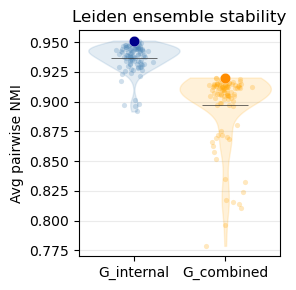

Internal:  μ=0.9371  σ=0.0118  medoid=0.9514
Combined:  μ=0.8971  σ=0.0303  medoid=0.9203


In [9]:
def plot_nmi_stability(stats_int, stats_comb):
    """Light side-by-side violin plots with jitter and medoid markers."""
    def avg_nmi(stats):
        m = stats['nmi_matrix']
        return (m.sum(axis=1) - 1) / (m.shape[0] - 1)

    nmi_int = avg_nmi(stats_int)
    nmi_comb = avg_nmi(stats_comb)

    fig, ax = plt.subplots(figsize=(3, 3))
    data = [nmi_int, nmi_comb]
    positions = [0, 1]

    vp = ax.violinplot(
        data,
        positions=positions,
        widths=1,
        showmeans=True,
        showmedians=False,
        showextrema=False,
    )
    for body, color in zip(vp['bodies'], ['steelblue', 'orange']):
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.15)
    vp['cmeans'].set_color('#333333')
    vp['cmeans'].set_linewidth(0.5)

    rng = np.random.default_rng(42)
    jitter_width = 0.1
    ax.scatter(
        rng.normal(positions[0], jitter_width, size=len(nmi_int)),
        nmi_int,
        s=14, color='steelblue', alpha=0.25, linewidths=0,
    )
    ax.scatter(
        rng.normal(positions[1], jitter_width, size=len(nmi_comb)),
        nmi_comb,
        s=14, color='orange', alpha=0.25, linewidths=0,
    )

    med_int = nmi_int[stats_int['medoid_idx']]
    med_comb = nmi_comb[stats_comb['medoid_idx']]
    ax.scatter(positions[0], med_int, s=55, color='darkblue', edgecolors='white', linewidths=0.2, zorder=2)
    ax.scatter(positions[1], med_comb, s=55, color='darkorange', edgecolors='white', linewidths=0.2, zorder=2)

    ax.set_xticks(positions)
    ax.set_xticklabels(['G_internal', 'G_combined'])
    ax.set_ylabel('Avg pairwise NMI')
    ax.set_title('Leiden ensemble stability')
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    print(f"Internal:  μ={nmi_int.mean():.4f}  σ={nmi_int.std():.4f}  medoid={med_int:.4f}")
    print(f"Combined:  μ={nmi_comb.mean():.4f}  σ={nmi_comb.std():.4f}  medoid={med_comb:.4f}")

plot_nmi_stability(infomap_internal_stats, infomap_combined_stats)

### Internal vs combined partition comparison

We align InfoMap partitions on common nodes and compare them with NMI, ARI, VI, and best-match Jaccard.
Goal: measure which communities stay stable and which are reorganized after adding BC edges.

### Semantic profile - Fields of Study (FOS)

For the top `TOP_N_COMMS` communities, we extract the `TOP_K` most frequent FOS labels.
Cell color encodes label share within each community.

FOS values are split on `;` and filtered to 4-digit sub-discipline codes (`level='sub'`, e.g. `0302 clinical medicine`).
This avoids composite strings that would distort frequency and purity metrics.

In [10]:
def extract_semantic_topk(partition, G, attr='FOS', level='sub',
                          top_n=TOP_N_COMMS, top_k=TOP_K):
    """Top-K most frequent labels per community for the largest top_n communities."""
    communities = sorted(partition.communities, key=len, reverse=True)[:top_n]
    rows = []
    for rank, comm in enumerate(communities, 1):
        counter = Counter()
        for node in comm:
            counter.update(parse_labels(G.nodes[node].get(attr), level=level))
        total = sum(counter.values())
        top_terms = counter.most_common(top_k)
        top_terms += [('N/A', 0)] * (top_k - len(top_terms))
        for pos, (term, cnt) in enumerate(top_terms, 1):
            rows.append({
                'CommunityRank': rank, 'CommunitySize': len(comm),
                'Position': pos, 'Term': term,
                'Count': cnt, 'Share': cnt / total if total else 0,
            })
    return pd.DataFrame(rows)


def plot_semantic_topk(df_int, df_comb, semantic_name='FOS', cmap='YlGnBu'):
    """Side-by-side heatmap of top-K labels per community."""
    top_k = int(df_int['Position'].max())

    def _build_matrix(df):
        comms = sorted(df['CommunityRank'].unique())
        val_mat = np.zeros((len(comms), top_k))
        lbl_mat = [['' for _ in range(top_k)] for _ in range(len(comms))]
        ylabels = []
        for i, c in enumerate(comms):
            rows = df[df['CommunityRank'] == c].sort_values('Position')
            ylabels.append(f"C{c} (n={int(rows['CommunitySize'].iloc[0])})")
            for _, r in rows.iterrows():
                j = int(r['Position']) - 1
                val_mat[i, j] = r['Share']
                term = textwrap.shorten(str(r['Term']), width=24, placeholder='...')
                lbl_mat[i][j] = f"{term}\n{int(r['Count'])} ({r['Share']*100:.1f}%)"
        return val_mat, lbl_mat, ylabels

    mat_i, lbl_i, y_i = _build_matrix(df_int)
    mat_c, lbl_c, y_c = _build_matrix(df_comb)
    vmax = max(mat_i.max(), mat_c.max(), 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
    for ax, mat, lbls, ylabs, title in [
        (axes[0], mat_i, lbl_i, y_i, f'InfoMap {semantic_name} — G_internal'),
        (axes[1], mat_c, lbl_c, y_c, f'InfoMap {semantic_name} — G_combined'),
    ]:
        im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xticks(range(top_k))
        ax.set_xticklabels([f'Top {i+1}' for i in range(top_k)])
        ax.set_yticks(range(len(ylabs)))
        ax.set_yticklabels(ylabs, fontsize=9)
        ax.set_xlabel('Label rank within community')
        ax.set_ylabel('Community')
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j, i, lbls[i][j], ha='center', va='center',
                        fontsize=7.5, color='black')
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9,
                 label='Label share within community')
    plt.show()

In [11]:
# FOS sub-discipline (4-digit)
df_fos_int  = extract_semantic_topk(infomap_internal, G_internal, attr='FOS', level='sub')
df_fos_comb = extract_semantic_topk(infomap_combined, G_combined, attr='FOS', level='sub')

# FOS macro-discipline (2-digit)
df_fos_l2_int  = extract_semantic_topk(infomap_internal, G_internal, attr='FOS', level='macro')
df_fos_l2_comb = extract_semantic_topk(infomap_combined, G_combined, attr='FOS', level='macro')

# SDG
df_sdg_int  = extract_semantic_topk(infomap_internal, G_internal, attr='SDG', level='all')
df_sdg_comb = extract_semantic_topk(infomap_combined, G_combined, attr='SDG', level='all')

# plot_semantic_topk(df_fos_int, df_fos_comb, semantic_name='FOS', cmap='PuBuGn')
# plot_semantic_topk(df_fos_l2_int, df_fos_l2_comb, semantic_name='FOS L2', cmap='PuBuGn')
# plot_semantic_topk(df_sdg_int, df_sdg_comb, semantic_name='SDG', cmap='YlOrBr')

### Size distribution

A compact two-panel view highlights structural differences between `G_internal` and `G_combined`:
- rank-size curve on log-log axes
- cumulative node coverage across ranked communities

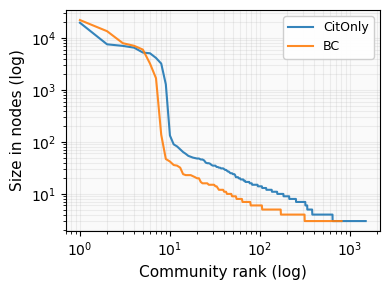


SIZE DISTRIBUTION SUMMARY
  Graph  n_comms  min   max mean median cov_10 cov_50 cov_80 cov_95  k_50%  k_80%  k_95%
CitOnly     1497    3 19725 45.7    3.0  87.7%  90.1%  90.9%  91.3%      3      7    427
     BC      807    3 22228 81.1    3.0  94.8%  95.8%  96.1%  96.3%      2      5     15

Legend:
  n_comms: number of communities
  min/max/mean/median: community size statistics
  cov_K: fraction of nodes covered by top-K communities
  k_XX%: number of communities needed to reach XX% coverage


{'CitOnly': {'n': 1497,
  'min': 3,
  'max': 19725,
  'mean': 45.74281897127589,
  'median': 3.0,
  'coverage': {10: 0.8773456781108986,
   50: 0.9009886531244067,
   80: 0.9092249952538809,
   95: 0.9125107700395754},
  'nodes_for_thr': {0.5: 3, 0.8: 7, 0.95: 427}},
 'BC': {'n': 807,
  'min': 3,
  'max': 22228,
  'mean': 81.06567534076828,
  'median': 3.0,
  'coverage': {10: 0.948012840110058,
   50: 0.9579027820238459,
   80: 0.9613420972179761,
   95: 0.9627178232956283},
  'nodes_for_thr': {0.5: 2, 0.8: 5, 0.95: 15}}}

In [12]:
def plot_size_distribution(partition_a, label_a, partition_b, label_b,
                           color_a='#2563EB', color_b='#F59E0B',
                           title='', thresholds=(0.50, 0.80, 0.95),
                           include_curves=False):
    """Rank-size plot + compact tabular summary with 10/50/80/95 coverage."""

    def _sizes(partition):
        sizes = sorted((len(c) for c in partition.communities), reverse=True)
        if not sizes:
            raise ValueError('Partition has no communities.')
        return np.asarray(sizes, dtype=float)

    def _summary(arr):
        cov = np.cumsum(arr) / arr.sum()
        summary = {
            'n': len(arr),
            'min': int(arr.min()),
            'max': int(arr.max()),
            'mean': float(arr.mean()),
            'median': float(np.median(arr)),
            'coverage': {k: float(arr[:min(k, len(arr))].sum() / arr.sum())
                         for k in (10, 50, 80, 95)},
            'nodes_for_thr': {
                thr: int(np.searchsorted(cov, thr, side='left') + 1)
                for thr in thresholds
            },
        }
        if include_curves:
            summary['cov'] = cov
        return summary, cov

    sizes_a = _sizes(partition_a)
    sizes_b = _sizes(partition_b)
    stats_a, cov_a = _summary(sizes_a)
    stats_b, cov_b = _summary(sizes_b)

    fig, ax = plt.subplots(figsize=(4, 3))
    rank_a = np.arange(1, len(sizes_a) + 1)
    rank_b = np.arange(1, len(sizes_b) + 1)

    ax.plot(rank_a, sizes_a, color=color_a, lw=1.5, alpha=0.9, label=label_a)
    ax.plot(rank_b, sizes_b, color=color_b, lw=1.5, alpha=0.9, label=label_b)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Community rank (log)', fontsize=11)
    ax.set_ylabel('Size in nodes (log)', fontsize=11)
    ax.grid(True, which='both', alpha=0.2)
    ax.set_facecolor('#FAFAFA')
    ax.legend(fontsize=9, loc='upper right', framealpha=0.95)

    plt.tight_layout()
    plt.show()

    table_data = []
    for label, stats in ((label_a, stats_a), (label_b, stats_b)):
        row = {
            'Graph': label,
            'n_comms': stats['n'],
            'min': stats['min'],
            'max': stats['max'],
            'mean': f"{stats['mean']:.1f}",
            'median': f"{stats['median']:.1f}",
            'cov_10': f"{stats['coverage'][10]:.1%}",
            'cov_50': f"{stats['coverage'][50]:.1%}",
            'cov_80': f"{stats['coverage'][80]:.1%}",
            'cov_95': f"{stats['coverage'][95]:.1%}",
            'k_50%': stats['nodes_for_thr'][0.50],
            'k_80%': stats['nodes_for_thr'][0.80],
            'k_95%': stats['nodes_for_thr'][0.95],
        }
        table_data.append(row)

    df_summary = pd.DataFrame(table_data)

    print("\nSIZE DISTRIBUTION SUMMARY")
    print("=" * 130)
    print(df_summary.to_string(index=False))
    print("=" * 130)
    print("\nLegend:")
    print("  n_comms: number of communities")
    print("  min/max/mean/median: community size statistics")
    print("  cov_K: fraction of nodes covered by top-K communities")
    print("  k_XX%: number of communities needed to reach XX% coverage")

    return {
        label_a: stats_a,
        label_b: stats_b,
    }


plot_size_distribution(
    infomap_internal, 'CitOnly',
    infomap_combined, 'BC',
    color_a='tab:blue', color_b='tab:orange',
    title='',
)

### Semantic purity

In [18]:
def compute_semantic_purity(clustering, G, attr='FOS', level='macro', min_size=10):
    """Weighted entropy and Gini per community (filtered by min_size)."""
    def _gini(counts):
        if len(counts) == 0:
            return 0.0
        s = np.sort(counts.astype(float))
        n = len(s)
        return (2 * np.sum(np.arange(1, n+1) * s)) / (n * s.sum()) - (n+1) / n

    entropies, ginis, sizes = [], [], []
    for comm in clustering.communities:
        if len(comm) < min_size:
            continue
        labels = []
        for node in comm:
            labels.extend(parse_labels(G.nodes[node].get(attr), level=level))
        if not labels:
            continue
        _, counts = np.unique(labels, return_counts=True)
        probs = counts / counts.sum()
        H = scipy_entropy(probs, base=2)
        H_max = np.log2(len(counts)) if len(counts) > 1 else 1.0
        entropies.append(H / H_max if H_max > 0 else 0.0)
        ginis.append(_gini(counts))
        sizes.append(len(comm))

    sizes = np.array(sizes)
    total = sizes.sum()
    return {
        'entropy': (np.array(entropies) * sizes).sum() / total,
        'gini':    (np.array(ginis) * sizes).sum() / total,
        'n_comms': len(sizes),
    }


def print_purity_comparison(clust_int, clust_comb, G_int, G_comb, min_size=10):
    print("\n" + "=" * 80)
    print("SEMANTIC PURITY ANALYSIS")
    print("=" * 80)
    for key, attr, level in [('FOS_L2', 'FOS', 'macro'), ('FOS', 'FOS', 'sub'), ('SDG', 'SDG', 'all')]:
        p_int  = compute_semantic_purity(clust_int,  G_int,  attr=attr, level=level, min_size=min_size)
        p_comb = compute_semantic_purity(clust_comb, G_comb, attr=attr, level=level, min_size=min_size)
        de = p_comb['entropy'] - p_int['entropy']
        dg = p_comb['gini'] - p_int['gini']
        e_verdict = "WORSE" if de > 0.01 else ("BETTER" if de < -0.01 else "SAME")
        g_verdict = "BETTER" if dg > 0.01 else ("WORSE" if dg < -0.01 else "SAME")
        print(f"\n{key}:")
        print(f"  Internal  | Entropy: {p_int['entropy']:.4f} | Gini: {p_int['gini']:.4f} | Comms: {p_int['n_comms']}")
        print(f"  Combined  | Entropy: {p_comb['entropy']:.4f} | Gini: {p_comb['gini']:.4f} | Comms: {p_comb['n_comms']}")
        print(f"  Δ Combined vs Internal: Entropy {de:+.4f} ({e_verdict}) | Gini {dg:+.4f} ({g_verdict})")
    print("=" * 80)

print_purity_comparison(infomap_internal, infomap_combined, G_internal, G_combined)


SEMANTIC PURITY ANALYSIS

FOS_L2:
  Internal  | Entropy: 0.6328 | Gini: 0.5380 | Comms: 182
  Combined  | Entropy: 0.4526 | Gini: 0.6506 | Comms: 46
  Δ Combined vs Internal: Entropy -0.1802 (BETTER) | Gini +0.1126 (BETTER)

FOS:
  Internal  | Entropy: 0.5593 | Gini: 0.7880 | Comms: 182
  Combined  | Entropy: 0.5070 | Gini: 0.8230 | Comms: 46
  Δ Combined vs Internal: Entropy -0.0523 (BETTER) | Gini +0.0351 (BETTER)

SDG:
  Internal  | Entropy: 0.5995 | Gini: 0.6771 | Comms: 162
  Combined  | Entropy: 0.5793 | Gini: 0.7043 | Comms: 48
  Δ Combined vs Internal: Entropy -0.0203 (BETTER) | Gini +0.0272 (BETTER)


### Fate analysis - impact of BC edges

Each community in `infomap_internal` is classified by its outcome in `infomap_combined`.

| Fate | Rule | Meaning |
|---|---|---|
| stable | best Jaccard >= 0.50 | mostly preserved |
| merged | >=2 internal communities map to one combined | unified by BC |
| split | one internal maps to >=2 combined | fragmented by BC |
| dissolved | best Jaccard < 0.20 | no clear counterpart |
| partial | otherwise | mixed reshaping |

Only communities with size >= 50 are analyzed to avoid micro-community noise.

Cross-domain merge: merged components have different dominant FOS labels (L2).

In [19]:
def _entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log(p + 1e-12))


def variation_of_information(labels_a, labels_b):
    return (_entropy(labels_a) + _entropy(labels_b)
            - 2.0 * mutual_info_score(labels_a, labels_b))


def _partition_to_sets(partition, allowed_nodes=None, min_size=1):
    result = []
    for comm in partition.communities:
        s = set(comm)
        if allowed_nodes is not None:
            s &= allowed_nodes
        if len(s) >= min_size:
            result.append(s)
    return result


def get_top_labels(comm, G, attr='FOS', level='sub', top_k=3):
    counter = Counter()
    for node in comm:
        counter.update(parse_labels(G.nodes[node].get(attr), level=level))
    total = sum(counter.values())
    if not total:
        return 'N/A'
    return ' | '.join(f"{k} ({v/total:.0%})" for k, v in counter.most_common(top_k))


def classify_community_fates(part_a, part_b, G,
                              name_a='A', name_b='B',
                              stable_thr=0.5, dissolved_thr=0.20,
                              min_size=50, attr='FOS', level='sub'):
    common = ({n for c in part_a.communities for n in c}
              & {n for c in part_b.communities for n in c})
    a_sets = _partition_to_sets(part_a, common, min_size)
    b_sets = _partition_to_sets(part_b, common, min_size)

    b_to_a_groups = defaultdict(list)
    rows = []

    for a_id, A in enumerate(a_sets):
        overlap = {b_id: len(A & B) / len(A | B)
                   for b_id, B in enumerate(b_sets) if A & B}

        if not overlap:
            rows.append({'a_id': a_id, 'size_a': len(A),
                         'best_jacc': 0.0, 'best_b_id': None,
                         'n_b_touched': 0, 'top_b_frac': 0.0,
                         'top_fos': get_top_labels(A, G, attr=attr, level=level),
                         'fate': 'dissolved'})
            continue

        best_b = max(overlap, key=overlap.get)
        top_b_frac = len(A & b_sets[best_b]) / len(A)
        n_touched = sum(1 for v in overlap.values() if v > 0.05)
        b_to_a_groups[best_b].append(a_id)
        rows.append({'a_id': a_id, 'size_a': len(A),
                     'best_jacc': round(overlap[best_b], 4), 'best_b_id': best_b,
                     'n_b_touched': n_touched,
                     'top_b_frac': round(top_b_frac, 3),
                     'top_fos': get_top_labels(A, G, attr=attr, level=level),
                     'fate': '__pending__'})

    df = pd.DataFrame(rows)

    b_group_size = df['best_b_id'].map(
        lambda bid: len(b_to_a_groups[bid]) if bid is not None else 0
    )
    df['fate'] = np.select(
        [df['fate'] == 'dissolved',
         df['best_jacc'] >= stable_thr,
         b_group_size > 1,
         (df['n_b_touched'] >= 2) & (df['top_b_frac'] < 0.70),
         df['best_jacc'] < dissolved_thr],
        ['dissolved', 'stable', 'merged', 'split', 'dissolved'],
        default='partial',
    )

    merge_events = []
    for b_id, a_ids in b_to_a_groups.items():
        if len(a_ids) < 2:
            continue
        event_comms = [a_sets[i] for i in a_ids]
        fos_profiles = [get_top_labels(c, G, attr=attr, top_k=2, level=level)
                        for c in event_comms]
        b_fos = get_top_labels(b_sets[b_id], G, attr=attr, top_k=3, level=level)
        unique_dom = len({p.split(' | ')[0].split(' (')[0] for p in fos_profiles})
        merge_events.append({
            'b_id': b_id, 'b_size': len(b_sets[b_id]),
            'n_merged': len(a_ids), 'a_sizes': [len(c) for c in event_comms],
            'fos_profiles': fos_profiles, 'b_fos': b_fos,
            'cross_domain': unique_dom > 1,
        })
    merge_events.sort(key=lambda x: x['b_size'], reverse=True)

    map_a = {n: cid for cid, s in enumerate(a_sets) for n in s}
    map_b = {n: cid for cid, s in enumerate(b_sets) for n in s}
    common_nodes = sorted(set(map_a) & set(map_b))
    la = np.array([map_a[n] for n in common_nodes])
    lb = np.array([map_b[n] for n in common_nodes])
    nmi = normalized_mutual_info_score(la, lb, average_method='arithmetic')
    vi = variation_of_information(la, lb)

    print(f'\n{"="*60}')
    print(f'  Fate Analysis: {name_a} -> {name_b}')
    print(f'{"="*60}')
    print(f'  Communities analysed (>={min_size} nodes): {len(df)}')
    print(f'  NMI: {nmi:.4f}  |  VI: {vi:.4f}')
    for fate, grp in df.groupby('fate'):
        pct = len(grp) / len(df) * 100
        print(f'    {fate:<12s} {len(grp):>4d}  ({pct:5.1f}%)  {"#" * int(pct/2)}')
    n_cross = sum(e['cross_domain'] for e in merge_events)
    print(f'\n  Merge events: {len(merge_events)}  |  Cross-domain: {n_cross}')

    return df, merge_events, {'NMI': nmi, 'VI': vi}


def print_merge_report(merge_events, top_n=10):
    print(f'\n{"="*65}')
    print(f'  TOP {top_n} MERGE EVENTS  (components >= 50 nodes)')
    print(f'{"="*65}')
    for i, ev in enumerate(merge_events[:top_n]):
        tag = '[cross-domain]' if ev['cross_domain'] else '[same-domain]'
        print(f'\n  [{i+1}] {tag}  -  {ev["n_merged"]} comms -> 1  (merged size: {ev["b_size"]})')
        print(f'       Merged FOS: {ev["b_fos"]}')
        for j, (fos, sz) in enumerate(zip(ev['fos_profiles'], ev['a_sizes'])):
            print(f'         C{j+1} (n={sz:>5d}): {fos}')

In [20]:
df_fates_infomap, merge_events_infomap, global_infomap = classify_community_fates(
    part_a   = infomap_internal,
    part_b   = infomap_combined,
    G        = G_combined,
    name_a   = 'InfoMap/Internal',
    name_b   = 'InfoMap/Combined',
    attr     = 'FOS',
    level    = 'sub',
    min_size = MIN_COMM_SIZE,
)


  Fate Analysis: InfoMap/Internal -> InfoMap/Combined
  Communities analysed (>=10 nodes): 112
  NMI: 0.7054  |  VI: 1.1762
    merged         86  ( 76.8%)  ######################################
    partial         1  (  0.9%)  
    stable         25  ( 22.3%)  ###########

  Merge events: 9  |  Cross-domain: 6


In [21]:
print_merge_report(merge_events_infomap, top_n=10)


  TOP 10 MERGE EVENTS  (components >= 50 nodes)

  [1] [cross-domain]  -  26 comms -> 1  (merged size: 18727)
       Merged FOS: 0302 clinical medicine (50%) | 0301 basic medicine (28%) | 0303 health sciences (16%)
         C1 (n=15982): 0302 clinical medicine (50%) | 0301 basic medicine (27%)
         C2 (n=   55): 0501 psychology and cognitive sciences (63%) | 0302 clinical medicine (18%)
         C3 (n=   33): 0302 clinical medicine (62%) | 0301 basic medicine (28%)
         C4 (n=   29): 0302 clinical medicine (71%) | 0501 psychology and cognitive sciences (29%)
         C5 (n=   32): 0302 clinical medicine (68%) | 0301 basic medicine (25%)
         C6 (n=   24): 0302 clinical medicine (82%) | 0206 medical engineering (14%)
         C7 (n=   25): 0302 clinical medicine (93%) | 0501 psychology and cognitive sciences (7%)
         C8 (n=   25): 0302 clinical medicine (91%) | 0301 basic medicine (5%)
         C9 (n=   22): 0301 basic medicine (35%) | 0303 health sciences (29%)
      

### Merge analysis - observations

Use the merge report to distinguish two patterns:
- large intra-domain consolidations (fragmentation resolved by BC)
- smaller cross-domain bridges (potential interdisciplinary links)

Takeaway: compare cross-domain share and top merged sizes to evaluate whether BC primarily consolidates existing domains or creates new thematic bridges.

### Summary - InfoMap

- BC increases edges strongly while modularity remains high (with the caveat that InfoMap optimizes codelength, not modularity).
- Ensemble stability is evaluated through pairwise NMI across 100 runs and medoid selection.
- Communities typically contract from internal to combined partitions, mainly through merges rather than splits.
- Fate analysis (size >=50): compare stable vs merged shares to quantify BC impact.
- Largest merges are often intra-disciplinary; cross-domain merges highlight candidate bridge areas.
- Semantic purity can be checked via weighted entropy and Gini (FOS and SDG).
- SDG structure can be used as a robustness check on high-level mission themes.